In [1]:
# # OPTIONAL: Load the "autoreload" extension so that code can change
# %load_ext autoreload
# # Always reload modules so that as you change code in src, it gets loaded
# %autoreload 2

In [2]:
# import pickle
# import numpy as np
# from pathlib import Path
# import pandas as pd
# from datetime import datetime

# import os
# from matplotlib import pyplot as plt


In [3]:
# def get_sessions_between_dates(mouse_id, experiment_type, start_date, end_date=None):
#     if end_date is None:
#         end_date = pd.to_datetime("today")  # Use today's date as default

#     # Convert start_date and end_date to datetime (allowing flexible parsing)
#     start_date = pd.to_datetime(start_date, dayfirst=False, yearfirst=True, errors="coerce")
#     end_date = pd.to_datetime(end_date, dayfirst=False, yearfirst=True, errors="coerce")

#     assert start_date <= end_date, "start_date should be less than or equal to end_date"

#     # Read CSV
#     summary_data = pd.read_csv(rf"Y:\{mouse_id}\data\random_dot_motion\{experiment_type}\{mouse_id}_summary.csv")

#     # Convert the 'date' column to datetime format with error handling
#     summary_data["date"] = pd.to_datetime(summary_data["date"], dayfirst=False, yearfirst=True, errors="coerce")

#     # Filter data based on date range
#     temp_pd = summary_data[(summary_data["date"] >= start_date) & (summary_data["date"] <= end_date)].copy()

#     return temp_pd["session"].values  # Ensure accessing the correct column

# def get_binned_accuracy(data, bin_size=10):
#     binned_accuracy = []
#     for idx in range(0, len(data), 50):
#         binned_accuracy.append(np.nanmean(data.outcome[idx : idx + 50]))
    
#     if len(data) % bin_size < bin_size/2:
#         binned_accuracy = binned_accuracy[:-1]
#     return np.array(binned_accuracy)


In [105]:
from pathlib import Path
import pandas as pd

def get_recent_sessions(data_dir=Path("Y:/"), last_X_business_days=None, start_date=None, end_date=None):
    # Ensure data_dir is a Path object
    data_dir = Path(data_dir)

    # Get all mouse ID folders except "XXX"
    mouse_ids = [f for f in data_dir.iterdir() if f.is_dir() and f.name != "XXX"]

    # Determine date range
    today = pd.to_datetime("today")  # Keep full timestamp
    if last_X_business_days is not None:
        start_date = today - pd.offsets.BDay(last_X_business_days)
        end_date = today
    else:
        start_date = pd.to_datetime(start_date, errors="coerce")
        end_date = pd.to_datetime(end_date, errors="coerce") if end_date else today

    # Validate date range
    if pd.isna(start_date) or pd.isna(end_date):
        raise ValueError("Invalid start_date or end_date format.")

    # Convert start_date and end_date to a consistent format
    date_format = "%Y-%m-%d"
    start_date_str = start_date.strftime(date_format)
    end_date_str = end_date.strftime(date_format)

    session_data = []
    required_columns = ["date", "start_weight", "end_weight", "baseline_weight", "experiment", "session"]

    for mouse in mouse_ids:
        history_path = mouse / "history.csv"

        try:
            history = pd.read_csv(history_path)
        except FileNotFoundError:
            continue
        
        # Convert date column dynamically to handle mixed formats
        history["date"] = pd.to_datetime(history["date"], format='mixed', errors="coerce")
        history = history.dropna(subset=["date"])  # Drop rows with invalid dates
        
        # Reformat history["date"] to match start_date and end_date format
        history["date"] = history["date"].dt.strftime(date_format)
        history["date"] = pd.to_datetime(history["date"], format=date_format, errors="coerce")  # Convert back to datetime

        # Apply date filtering
        history = history[(history["date"] >= start_date) & (history["date"] <= end_date)]

        if history.empty:
            continue  # Skip if no relevant data

        # Ensure required columns exist
        history = history.reindex(columns=required_columns, fill_value=pd.NA)
        history["start_weight"] = history["start_weight"] / history["baseline_weight"] * 100
        history["end_weight"] = history["end_weight"] / history["baseline_weight"] * 100
        history["mouse_id"] = mouse.name

        session_data.append(history[["mouse_id", "date", "start_weight", "end_weight", "experiment", "session"]])

    # Concatenate all results into a single DataFrame
    return pd.concat(session_data, ignore_index=True) if session_data else pd.DataFrame()




In [106]:
# Example usage
# session_info = get_recent_sessions(data_dir=Path("Y:/"), last_X_business_days=2)
session_info = get_recent_sessions(data_dir=Path("Y:/"), start_date="2025-02-02", end_date="2025-02-05")

session_info

,mouse_id,date,start_weight,end_weight,experiment,session
0,DBM22,2025-02-03,86.538462,87.980769,rt_directional_training,21_1
1,DBM22,2025-02-03,87.980769,89.903846,rt_directional_training,21_2
2,DBM22,2025-02-04,85.096154,87.019231,rt_directional_training,22_1
3,DBM22,2025-02-04,88.942308,89.903846,rt_directional_training,22_2
4,DBM22,2025-02-05,86.057692,87.019231,rt_directional_training,23_1
5,DBM23,2025-02-03,98.522167,103.940887,rt_directional_training,21_1
6,DBM23,2025-02-04,87.192118,88.669951,rt_directional_training,22_1
7,DBM23,2025-02-04,101.477833,102.463054,rt_directional_training,22_2
8,DBM23,2025-02-05,99.014778,100.492611,rt_directional_training,23_1
9,DBM24,2025-02-03,88.780488,89.268293,rt_directional_training,21_1


## Binned Accuracy

In [62]:
for mouse_id in session_info.mouse_id.unique():
    mouse_sessions = session_info[session_info.mouse_id == mouse_id]
    for experiment in mouse_sessions.experiment.unique():
        experiment_sessions = mouse_sessions[mouse_sessions.experiment == experiment]
        sessions = get_sessions_between_dates(mouse_id, experiment, experiment_sessions.date.min(), experiment_sessions.date.max())
        print(f"{mouse_id} {experiment}: {len(sessions)} sessions")

DBM27 rt_directional_training: 0 sessions


In [53]:
# import pandas as pd
# import matplotlib.pyplot as plt
# mice = ["DBM22", "DBM23", "DBM24", "DBM26", "DBM27", "DBM28", "DBM30", "DBM32", "DBM33", "DBM34"]
# experiment_type = "rt_directional_training"
# start_date = "Feb-04-2025"
# end_date = None

# bin_size = 10
# binned_accuracy = {}

# for mouse_id in mice:

#     sessions = get_sessions_between_dates(mouse_id=mouse_id, experiment_type=experiment_type, start_date=start_date, end_date=end_date)

#     session_accuracies = []  # Temporary list to collect accuracy values
#     print(sessions)
#     for session_id in sessions:
#         session_data = pd.read_csv(rf"Y:\{mouse_id}\data\random_dot_motion\{experiment_type}\{session_id}\{mouse_id}_trial.csv", index_col=0)
#         session_data["mouse_id"] = mouse_id
#         session_data["session_id"] = session_id
#         session_data = session_data[session_data["outcome"].notna()]
#         session_data = session_data[~session_data["is_correction_trial"]]
        
#         session_accuracies.append(get_binned_accuracy(session_data, bin_size=bin_size))

#     # Convert to DataFrame where each row is a session
#     binned_accuracy[mouse_id] = pd.DataFrame(session_accuracies)

['22_1' '22_2']
['22_1' '22_2']
['22_1']
['18_1' '18_2']
['20_1' '20_2']
['18_1' '18_2']
['18_1' '18_2']
['21_1' '21_2']
['21_1' '21_2']
['22_1' '22_2']


C:\Users\mablab\AppData\Local\Temp\ipykernel_17924\366373523.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("cool", temp_accuracy.shape[0])


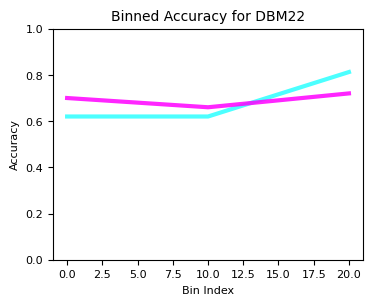

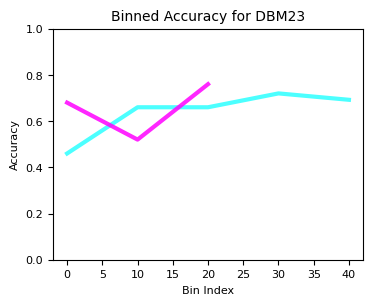

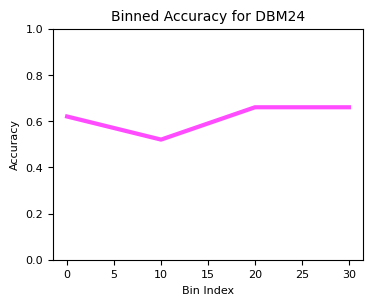

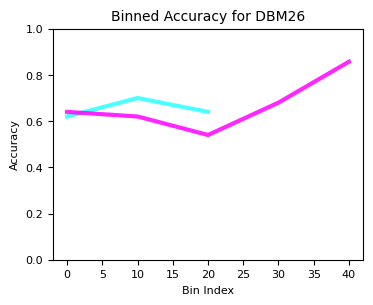

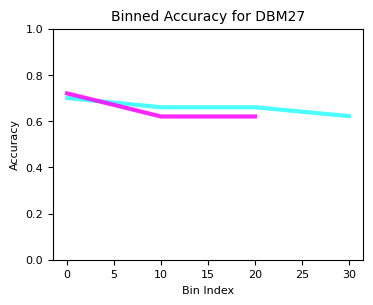

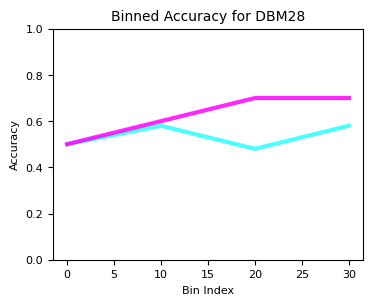

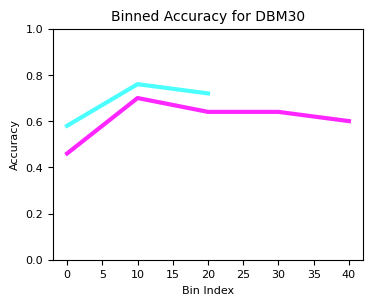

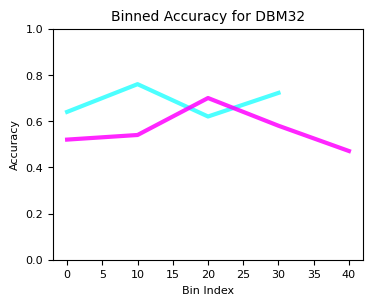

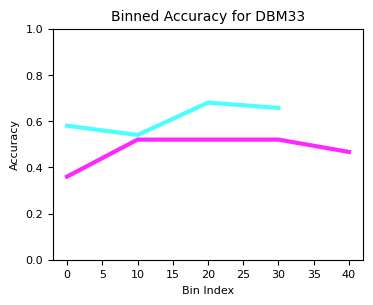

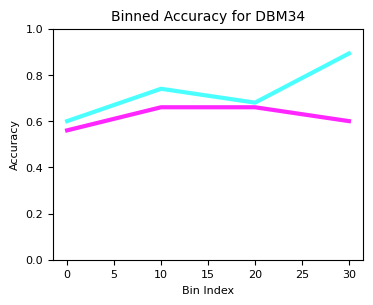

In [48]:
# import matplotlib.cm as cm
# for mouse_id in mice:

#     plt.figure(figsize=(4, 3))
#     temp_accuracy = binned_accuracy[mouse_id]
#     cmap = cm.get_cmap("cool", temp_accuracy.shape[0])
#     for i, row in enumerate(temp_accuracy.values):
#         alpha = 0.7 + (0.3 * i / len(temp_accuracy))  # Gradual fade-in
#         plt.plot(np.arange(0, len(row))*bin_size, row, color=cmap(i), alpha=alpha, linewidth=3)

#     plt.xlabel("Trial Number", fontsize=8)
#     plt.ylabel("Accuracy", fontsize=8)
#     plt.tick_params(axis="both", labelsize=8)
#     plt.ylim([0,1])

#     plt.title(f"Binned Accuracy for {mouse_id}", fontsize=10)
#     plt.show()

# Time to Reach X correct trials

In [6]:
# data = session_data

In [28]:
# idx = []
# thresholds = [100, 125, 150, 175]

# for threshold in thresholds:
#     found = np.where(np.cumsum(data.outcome) > threshold)[0]
#     if found.size > 0:
#         idx.append(found[0])
#     else:
#         break

# idx = np.array(idx)  # Convert to NumPy array for numerical operations
# delta_time = data["fixation_onset"] = pd.to_timedelta(data["fixation_onset"].iloc[idx + 1])
# delta_time = delta_time.dt.total_seconds() / 60
# print(delta_time)

idx_attempt
323    12.380373
392    16.164291
472    19.730383
546    23.831794
Name: fixation_onset, dtype: float64


In [29]:
# def time_to_X_correct(data):
#     idx = []
#     thresholds = [100, 125, 150, 175]

#     for threshold in thresholds:
#         found = np.where(np.cumsum(data.outcome) > threshold)[0]
#         if found.size > 0:
#             idx.append(found[0])
#         else:
#             break

#     idx = np.array(idx)  # Convert to NumPy array for numerical operations
#     delta_time = data["fixation_onset"] = pd.to_timedelta(data["fixation_onset"].iloc[idx + 1])
#     delta_time = delta_time.dt.total_seconds() / 60
#     return np.array(delta_time.values)

In [30]:
# import pandas as pd
# import matplotlib.pyplot as plt

# mice = ["DBM22", "DBM23", "DBM24", "DBM26", "DBM27", "DBM28", "DBM30", "DBM32", "DBM33", "DBM34"]
# experiment_type = "rt_directional_training"
# start_date = "Jan-27-2025"
# end_date = None

# time_dict = {}

# for mouse_id in mice:

#     sessions = get_sessions_between_dates(mouse_id=mouse_id, experiment_type=experiment_type, start_date=start_date, end_date=end_date)

#     time_to_correct_Xtrials = []  # Temporary list to collect accuracy values

#     for session_id in sessions:
#         session_data = pd.read_csv(rf"Y:\{mouse_id}\data\random_dot_motion\{experiment_type}\{session_id}\{mouse_id}_trial.csv", index_col=0)
#         session_data["mouse_id"] = mouse_id
#         session_data["session_id"] = session_id
#         session_data = session_data[session_data["outcome"].notna()]

#         time_to_correct_Xtrials.append(time_to_X_correct(session_data))

#     # Convert to DataFrame where each row is a session
#     time_dict[mouse_id] = pd.DataFrame(time_to_correct_Xtrials)


# summary_list = []  # List to store results
# for mouse_id in mice:
#     mean_values = np.nanmean(time_dict[mouse_id], axis=0)  # Compute mean for each column
#     summary_list.append([mouse_id] + list(mean_values))  # Append mouse ID + mean values
# # Convert to DataFrame for better readability
# summary_df = pd.DataFrame(summary_list, columns=["Mouse ID", "Correct_100", "Correct_125", "Correct_150", "Correct_175"])
# print(summary_df)

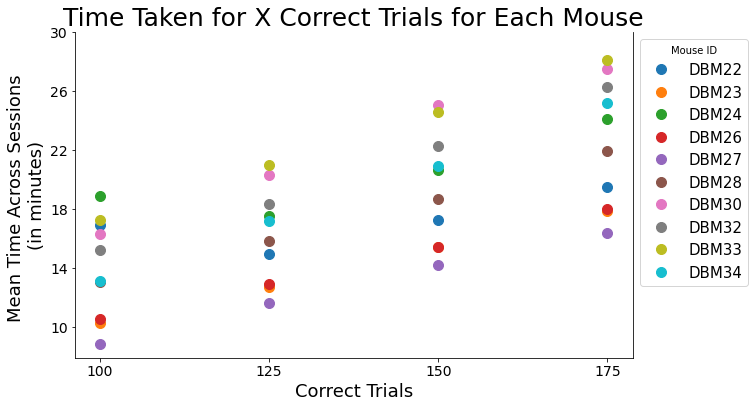

In [85]:
# import matplotlib.pyplot as plt

# # Define the correct x-axis values (time points corresponding to trials)
# time_points = [100, 125, 150, 175]  # These are your trial thresholds

# # Plot the data with time on the x-axis
# plt.figure(figsize=(10, 6))
# plt.plot(time_points, summary_df.iloc[:, 1:].T, marker="o", ls='', ms=10)

# # Labels and title
# plt.xlabel("Correct Trials", fontsize=18)
# plt.ylabel("Mean Time Across Sessions \n(in minutes)", fontsize=18)
# plt.title("Time Taken for X Correct Trials for Each Mouse", fontsize=25)
# plt.xticks(time_points, fontsize=14)  # Ensure correct x-axis labels
# plt.yticks([10, 14, 18, 22, 26, 30], fontsize=14)
# plt.legend(summary_df["Mouse ID"], title="Mouse ID", bbox_to_anchor=(1, 1), fontsize=15)  # Add a legend
# # remove top and right lines from the graph
# plt.gca().spines['top'].set_visible(False)

# plt.show()

In [34]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd

from src.utils import pmf_utils

DATA_DIR = data_dir = Path("Y:/")


def get_recent_sessions(last_X_business_days=None, start_date=None, end_date=None):

    # Get all mouse ID folders except "XXX"
    mouse_ids = [f for f in DATA_DIR.iterdir() if f.is_dir() and f.name != "XXX"]

    # Determine date range
    today = pd.to_datetime("today")  # Keep full timestamp
    if last_X_business_days is not None:
        start_date = today - pd.offsets.BDay(last_X_business_days)
        end_date = today
    else:
        start_date = pd.to_datetime(start_date, errors="coerce")
        end_date = pd.to_datetime(end_date, errors="coerce") if end_date else today

    # Validate date range
    if pd.isna(start_date) or pd.isna(end_date):
        raise ValueError("Invalid start_date or end_date format.")

    # Convert start_date and end_date to a consistent format
    date_format = "%Y-%m-%d"
    start_date_str = start_date.strftime(date_format)
    end_date_str = end_date.strftime(date_format)

    session_data = []
    required_columns = ["date", "start_weight", "end_weight", "baseline_weight", "experiment", "session"]

    for mouse in mouse_ids:
        history_path = mouse / "history.csv"

        try:
            history = pd.read_csv(history_path)
        except FileNotFoundError:
            continue

        # Convert date column dynamically to handle mixed formats
        history["date"] = pd.to_datetime(history["date"], format="mixed", errors="coerce")
        history = history.dropna(subset=["date"])  # Drop rows with invalid dates

        # Reformat history["date"] to match start_date and end_date format
        history["date"] = history["date"].dt.strftime(date_format)
        history["date"] = pd.to_datetime(history["date"], format=date_format, errors="coerce")  # Convert back to datetime

        # Apply date filtering
        history = history[(history["date"] >= start_date) & (history["date"] <= end_date)]

        if history.empty:
            continue

        # Ensure required columns exist
        history = history.reindex(columns=required_columns, fill_value=pd.NA)
        history["start_weight"] = history["start_weight"] / history["baseline_weight"] * 100
        history["end_weight"] = history["end_weight"] / history["baseline_weight"] * 100
        history["mouse_id"] = mouse.name

        session_data.append(history[["mouse_id", "date", "start_weight", "end_weight", "experiment", "session"]])

    # Concatenate all results into a single DataFrame
    return pd.concat(session_data, ignore_index=True) if session_data else pd.DataFrame()


def preprocess_data(data):
    data = data.dropna(subset=["outcome"])
    data = data[data.is_correction_trial == False]
    return data


def get_binned_accuracy(data, bin_size=10):
    outcome_array = data["outcome"].astype(float).to_numpy()
    num_bins = len(outcome_array) // bin_size
    binned_accuracy = [np.nanmean(outcome_array[i * bin_size : (i + 1) * bin_size]) * 100 for i in range(num_bins)]
    binned_indices = np.arange(num_bins) * bin_size
    return binned_indices, np.array(binned_accuracy)

In [54]:
OUTPUT_DATA_DIR = Path("D:/PROJECTS/research/mouse-training-analysis/data")
import pickle

In [56]:
# Get session information for recent sessions
session_info = get_recent_sessions(last_X_business_days=30)
session_info.date = pd.to_datetime(session_info.date).dt.date
analyzed_data = {}

# Process each mouse and session
for mouse_id in session_info.mouse_id.unique():
    mouse_sessions = session_info[session_info.mouse_id == mouse_id]
    for idx_date, date in enumerate(mouse_sessions.date.unique()):
        sessions = mouse_sessions[mouse_sessions.date == date].reset_index()
        for idx, metadata in sessions.iterrows():
            trial_info = pd.read_csv(
                data_dir / mouse_id / "data/random_dot_motion" / metadata.experiment / metadata.session / f"{mouse_id}_trial.csv"
            )
            trial_info = preprocess_data(trial_info)
            binned_trial, binned_accuracy = get_binned_accuracy(trial_info, bin_size=20)
            coherences, accuracies = pmf_utils.get_accuracy_data(trial_info)
            _, median_reaction_time = pmf_utils.get_chronometric_data(trial_info)

            analyzed_data[metadata["index"]] = {
                "binned_trials": binned_trial,
                "binned_accuracies": binned_accuracy,
                "coherences": coherences,
                "accuracy": accuracies,
                "median_reaction_time": median_reaction_time,
            }

# Save the updated DataFrame to a new CSV file
session_info.to_csv(Path(OUTPUT_DATA_DIR/"session_info.csv"), index=False)
# save master_dict as pickle file
with open(Path(OUTPUT_DATA_DIR/'analyzed_data.pkl'), 'wb') as f:
    pickle.dump(analyzed_data, f)

In [39]:
session_info


,mouse_id,date,start_weight,end_weight,experiment,session,binned_trial,binned_accuracy,coherences,accuracy,median_reaction_time
0,DBM22,2025-01-07,87.019231,87.500000,rt_directional_training,3_1,[ 0 20 40 60 80 100 120 140 160 180 200 2...,[ 85. 90. 95. 95. 90. 95. 95. 95. 95. ...,[100],[95],['1.083']
1,DBM22,2025-01-08,83.653846,84.134615,rt_directional_training,4_1,[ 0 20 40 60 80 100 120 140 160 180 200],[ 80. 50. 70. 95. 100. 100. 100. 100. 100. ...,[-100],[87],['1.371']
2,DBM22,2025-01-10,84.134615,86.538462,rt_directional_training,5_1,[ 0 20 40 60 80 100 120 140 160 180 200 2...,[ 65. 100. 100. 100. 100. 95. 95. 100. 100. ...,[100],[97],['1.759']
3,DBM22,2025-01-13,86.057692,85.576923,rt_directional_training,6_1,[ 0 20 40 60 80 100 120 140 160 180 200 2...,[ 85. 95. 100. 100. 90. 85. 85. 100. 100. ...,[-100],[96],['1.294']
4,DBM22,2025-01-14,81.250000,83.653846,rt_directional_training,7_1,[ 0 20 40 60 80 100 120 140 160 180 200 2...,[100. 100. 100. 100. 100. 100. 100. 95. 100. ...,[100],[99],['1.157']
...,...,...,...,...,...,...,...,...,...,...,...
300,DBM40,2025-01-22,84.939759,86.144578,rt_directional_training,9_1,[ 0 20 40 60 80 100 120 140 160 180 200 2...,[75. 55. 40. 30. 55. 60. 45. 35. 40. 40. 45. 4...,[-100 100],[54 39],['0.391' '0.578']
301,DBM40,2025-01-23,84.337349,84.939759,rt_directional_training,10_1,[ 0 20 40 60 80 100 120 140 160 180 200 2...,[45. 55. 75. 45. 40. 30. 45. 40. 25. 50. 50. 4...,[-100 100],[54 39],['0.291' '0.825']
302,DBM40,2025-01-24,84.337349,85.542169,rt_directional_training,11_1,[ 0 20 40 60 80 100 120 140 160 180 200 2...,[35. 50. 50. 50. 40. 70. 50. 45. 70. 70. 50. 3...,[-100 100],[48 54],['0.366' '0.483']
303,DBM40,2025-01-27,97.590361,98.192771,rt_directional_training,12_1,[ 0 20 40 60 80 100 120 140 160 180 200 2...,[55. 60. 65. 35. 50. 45. 65. 55. 40. 35. 40. 4...,[-100 100],[52 45],['0.287' '0.531']


In [24]:
import ast
import re  
# Function to fix and safely evaluate the string

import re
import ast
import numpy as np


# Function to safely parse and evaluate the string, ensuring correct format
def safe_literal_eval(x):
    try:
        # Only apply if it's a string
        if isinstance(x, str):
            # Step 1: Remove leading/trailing spaces
            x = x.strip()
            # Step 2: Remove any leading commas or spaces before the first element
            x = re.sub(r"^\s*,", "", x)
            # Step 3: Replace multiple spaces between numbers with a single comma
            x = re.sub(r"\s+", ",", x)
            # Step 4: Ensure no extra commas at the end
            x = re.sub(r",\s*$", "", x)
            # Step 5: Try to evaluate the cleaned-up string
            return np.array(ast.literal_eval(x))
        else:
            return x
    except (ValueError, SyntaxError) as e:
        # Log any problematic value and return it unchanged
        print(f"Skipping invalid format: {x}")
        return x


# Apply the function to the relevant columns
session_info["binned_trial"] = session_info["binned_trial"].apply(safe_literal_eval)
session_info["binned_accuracy"] = session_info["binned_accuracy"].apply(safe_literal_eval)
session_info["coherences"] = session_info["coherences"].apply(safe_literal_eval)
session_info["accuracy"] = session_info["accuracy"].apply(safe_literal_eval)
session_info["median_reaction_time"] = session_info["median_reaction_time"].apply(safe_literal_eval)


DATA_FILE = Path("D:/PROJECTS/research/mouse-training-analysis/data/session_info.csv")
session_info = pd.read_csv(DATA_FILE)

# Apply the function to the relevant columns
session_info["binned_trial"] = session_info["binned_trial"].apply(safe_literal_eval)
session_info["binned_accuracy"] = session_info["binned_accuracy"].apply(safe_literal_eval)
session_info["coherences"] = session_info["coherences"].apply(safe_literal_eval)
session_info["accuracy"] = session_info["accuracy"].apply(safe_literal_eval)
session_info["median_reaction_time"] = session_info["median_reaction_time"].apply(safe_literal_eval)


session_info["date"] = pd.to_datetime(session_info["date"]).dt.date
# Date Range Selection
start_date = '2025-02-02'
end_date = '2025-02-05'
# Mouse Selection
selected_mice = ["DBM22"]
# # Filter data based on selected date range
# filtered_sessions = session_info[(session_info.date >= start_date) & (session_info.date <= end_date)]


# # Show data for selected mice
# for mouse_id in selected_mice:
#     mouse_sessions = session_info[session_info.mouse_id == mouse_id]
#     mouse_sessions = mouse_sessions.sort_values(by="date", ascending=True)

#     for idx_date, date in enumerate(mouse_sessions.date.unique()):
#         sessions = mouse_sessions[mouse_sessions.date == date].reset_index()

#         for idx, metadata in sessions.iterrows():
#             print(metadata['binned_trial'])

Skipping invalid format: [,0,20,40,60,80,100,120,140,160,180,200,220,240,260,280,300,320,340,360,380,400,420,440]
Skipping invalid format: [,0,20,40,60,80,100,120,140,160,180,200]
Skipping invalid format: [,0,20,40,60,80,100,120,140,160,180,200,220,240,260,280,300,320,340,360,380,400,420,440,460,480,500,520,540,560,580,600]
Skipping invalid format: [,0,20,40,60,80,100,120,140,160,180,200,220,240,260,280,300]
Skipping invalid format: [,0,20,40,60,80,100,120,140,160,180,200,220,240,260,280,300,320,340,360,380,400,420,440,460,480,500,520]
Skipping invalid format: [,0,20,40,60,80,100,120]
Skipping invalid format: [,0,20,40,60,80,100,120,140,160,180,200,220]
Skipping invalid format: [,0,20,40]
Skipping invalid format: [,0,20,40,60]
Skipping invalid format: [,0,20,40,60,80,100]
Skipping invalid format: [,0,20,40,60,80,100,120,140]
Skipping invalid format: [,0,20,40,60]
Skipping invalid format: [,0,20,40,60,80,100,120,140,160,180,200,220,240,260,280,300,320,340,360,380,400,420,440,460,480]
Sk